In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid")

In [3]:
train_df = pd.read_csv('data/train.csv')
print(f"Total training samples: {train_df.shape[0]}")
train_df.head()

Total training samples: 40000


,comment,price_value
0,قیمت مناسب وکیفیت خوب پیشنهادمیکنم حتما خرید کنید,1
1,به اندازه یک میلیمتر دورتادور گوشی خالی میماند...,0
2,از همه نظر عالی و یک خرید خوب در قیمت حدود۴۰ ...,1
3,فقط یک بار هر یک ربع ساعت 1 درصد شارژ کرد بعدش...,0
4,قیمت این کالا خیلی تغییر میکنه . من خریدم چندر...,1


### checking class distribution

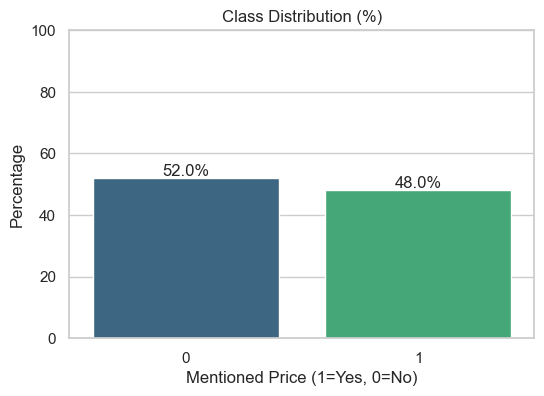

In [10]:
class_counts = train_df['price_value'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette="viridis",
    legend=False
)
plt.title("Class Distribution (%)")
plt.xlabel("Mentioned Price (1=Yes, 0=No)")
plt.ylabel("Percentage")
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

In [13]:
train_df['comment'].isna().sum()

np.int64(0)

In [5]:
X_raw = train_df['comment'].fillna('')
y = train_df['price_value']

print("Vectorizing text data...")
tfidf = TfidfVectorizer(max_features=25000, min_df=3, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(X_raw)

print(f"Feature Matrix Shape: {X_tfidf.shape}")
print(f"Sparsity: {100 * (1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])):.2f}%")

Vectorizing text data...
Feature Matrix Shape: (40000, 25000)
Sparsity: 99.88%


### 3. Model Selection & Benchmarking
We evaluate three linear and probabilistic classifiers using **5-Fold Stratified Cross-Validation** on the 25,000-dimensional TF-IDF matrix (`99.88%` sparsity):
- **MultinomialNB:** Fast probabilistic baseline.
- **Logistic Regression:** Linear classifier with log-loss optimization.
- **LinearSVC:** Support Vector Machine optimized via `liblinear` for high-dimensional sparse text.

In [6]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVC': LinearSVC(random_state=42, class_weight='balanced')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("Running 5-Fold Cross Validation...\n")
for name, model in models.items():
    print(f"Evaluating {name}...")
    cv_scores = cross_validate(model, X_tfidf, y, cv=cv, scoring=['f1_macro', 'accuracy'], n_jobs=-1)
    
    results.append({
        'Model': name,
        'F1-Macro (Mean)': cv_scores['test_f1_macro'].mean(),
        'Accuracy (Mean)': cv_scores['test_accuracy'].mean(),
        'Fit Time (s)': cv_scores['fit_time'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by='F1-Macro (Mean)', ascending=False)
display(results_df)

Running 5-Fold Cross Validation...

Evaluating Naive Bayes...


Evaluating Logistic Regression...
Evaluating Linear SVC...


,Model,F1-Macro (Mean),Accuracy (Mean),Fit Time (s)
2,Linear SVC,0.894506,0.894875,0.324145
1,Logistic Regression,0.890473,0.891175,0.135468
0,Naive Bayes,0.844310,0.844850,0.022576


### 4. Model Persistence & Interpretability (Feature Importance)
LinearSVC computes a separating hyperplane defined by $\mathbf{w}^T \mathbf{x} + b = 0$. By inspecting the learned weight vector $\mathbf{w}$, we can directly audit which unigrams and bigrams drive positive (`price_value = 1`) and negative (`price_value = 0`) predictions.

Loading existing model artifact from '../models/price_mention_model.pkl'...


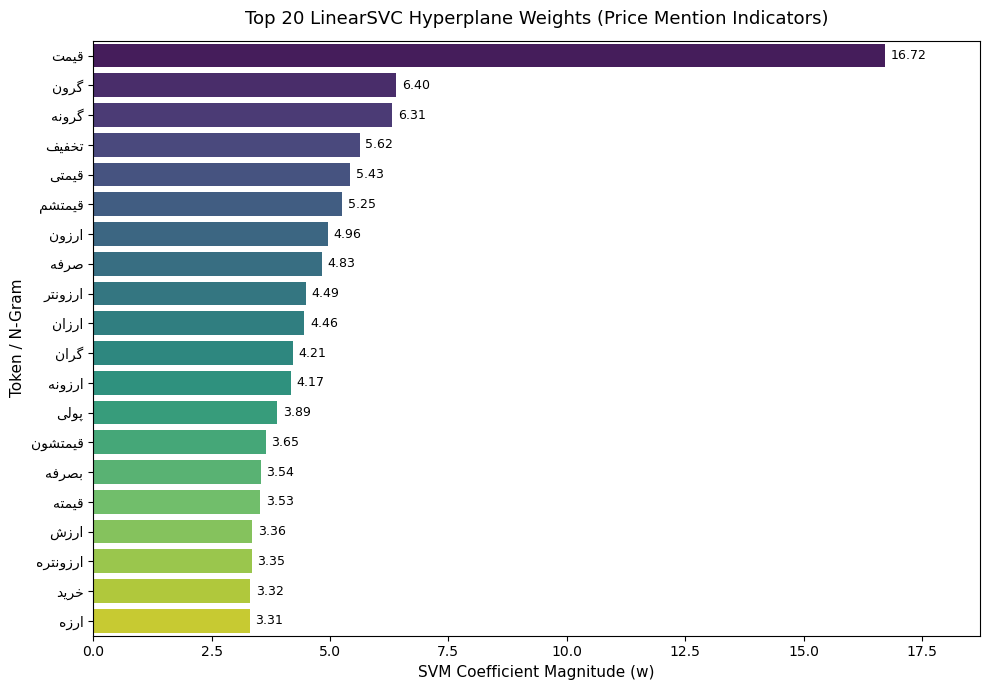

,Raw_Feature,Weight
0,قیمت,16.716329
1,گرون,6.397380
2,گرونه,6.310741
3,تخفیف,5.623932
4,قیمتی,5.428180
5,قیمتشم,5.252683
6,ارزون,4.962485
7,صرفه,4.832183
8,ارزونتر,4.489029
9,ارزان,4.458488


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Optional helper for proper RTL Persian text rendering in Matplotlib
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    def format_persian_label(text: str) -> str:
        return get_display(arabic_reshaper.reshape(text))
except ImportError:
    def format_persian_label(text: str) -> str:
        return text

MODEL_PATH = "../models/price_mention_model.pkl"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

# 1. Check if serialized model artifact already exists to avoid redundant training
if os.path.exists(MODEL_PATH):
    print(f"Loading existing model artifact from '{MODEL_PATH}'...")
    pipeline = joblib.load(MODEL_PATH)
else:
    print("Model artifact not found. Training LinearSVC pipeline...")
    pipeline = Pipeline([
        ("vectorizer", TfidfVectorizer(max_features=25000, min_df=3, ngram_range=(1, 2))),
        ("classifier", LinearSVC(random_state=42, class_weight="balanced", dual="auto"))
    ])
    pipeline.fit(X_raw, y)
    joblib.dump(pipeline, MODEL_PATH)
    print(f"Model successfully trained and cached at '{MODEL_PATH}'.")

# 2. Extract feature names and hyperplane coefficients (w)
vectorizer = pipeline.named_steps["vectorizer"]
classifier = pipeline.named_steps["classifier"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = classifier.coef_.flatten()

# 3. Get Top 20 Positive (Price-Related) and Top 10 Negative (Non-Price) features
top_k = 20
top_positive_idx = np.argsort(coefficients)[-top_k:][::-1]
top_negative_idx = np.argsort(coefficients)[:10]

top_pos_df = pd.DataFrame({
    "Feature": [format_persian_label(f) for f in feature_names[top_positive_idx]],
    "Raw_Feature": feature_names[top_positive_idx],
    "Weight": coefficients[top_positive_idx]
})

# 4. Plot Top 20 Price-Indicative Features
plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=top_pos_df,
    x="Weight",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 20 LinearSVC Hyperplane Weights (Price Mention Indicators)", fontsize=13, pad=12)
plt.xlabel("SVM Coefficient Magnitude (w)", fontsize=11)
plt.ylabel("Token / N-Gram", fontsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=4, fontsize=9)

plt.xlim(0, top_pos_df["Weight"].max() * 1.12)
plt.tight_layout()
plt.savefig("../assets/feature_importance.png", dpi=300)
plt.show()

# Display clean tabular summary for reference
display(top_pos_df[["Raw_Feature", "Weight"]].head(10))